# Restaurant Rating Prediction

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("restaurant.csv")

In [3]:
dataset.head(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [5]:
dataset.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [6]:
dataset.duplicated().sum()

np.int64(0)

In [7]:
dataset.isna().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [8]:
dataset.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [9]:
# Group by city and calculate average cost

dataset.groupby('City')["Average Cost for two"].mean().sort_values(ascending=False)

City
Jakarta           308437.500000
Tangerang         250000.000000
Bogor             160000.000000
Bandung           150000.000000
Pasay City          3333.333333
                      ...      
Lakeview              10.000000
Lakes Entrance         7.000000
Inverloch              7.000000
Dicky Beach            7.000000
Miller                 0.000000
Name: Average Cost for two, Length: 141, dtype: float64

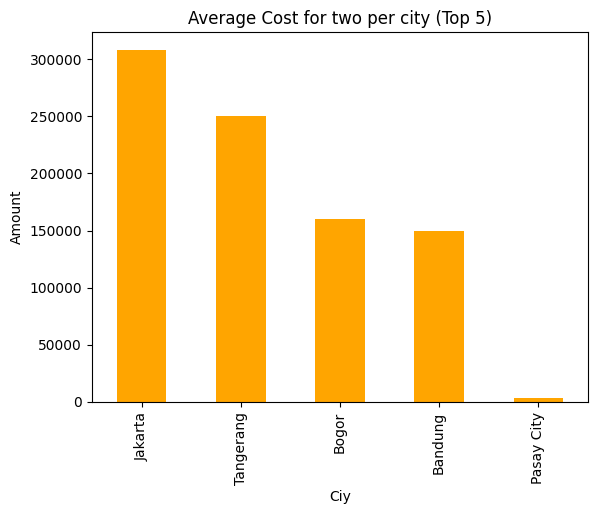

In [10]:
dataset.groupby('City')["Average Cost for two"].mean().sort_values(ascending=False).head().plot(kind="bar",color="orange")
plt.title("Average Cost for two per city (Top 5)")
plt.xlabel("Ciy")
plt.ylabel("Amount")
plt.show()

In [11]:
# Cusines total number of Votes
dataset.groupby("Cuisines")["Votes"].sum().sort_values(ascending = False)

Cuisines
North Indian, Mughlai            53747
North Indian                     46241
North Indian, Chinese            42012
Cafe                             30657
Chinese                          21925
                                 ...  
Chinese, Fast Food, Pizza            0
South Indian, Chinese, Mithai        0
South Indian, Pizza, Chinese         0
Cafe, North Eastern                  0
Afghani, North Indian                0
Name: Votes, Length: 1825, dtype: int64

In [12]:
cuisines_votes = dataset.groupby("Cuisines")["Votes"].sum().reset_index()

In [13]:
cuisines_votes.head()

,Cuisines,Votes
0,Afghani,39
1,"Afghani, Mughlai, Chinese",2
2,"Afghani, North Indian",0
3,"Afghani, North Indian, Pakistani, Arabian",3
4,African,373


In [14]:
cuisines_votes.shape

(1825, 2)

In [15]:
cuisines_votes[cuisines_votes["Votes"] != 0]

,Cuisines,Votes
0,Afghani,39
1,"Afghani, Mughlai, Chinese",2
3,"Afghani, North Indian, Pakistani, Arabian",3
4,African,373
5,"African, Portuguese",265
...,...,...
1820,"Western, Asian, Cafe",259
1821,"Western, Fusion, Fast Food",32
1822,World Cuisine,95
1823,"World Cuisine, Mexican, Italian",115


<Figure size 700x600 with 0 Axes>

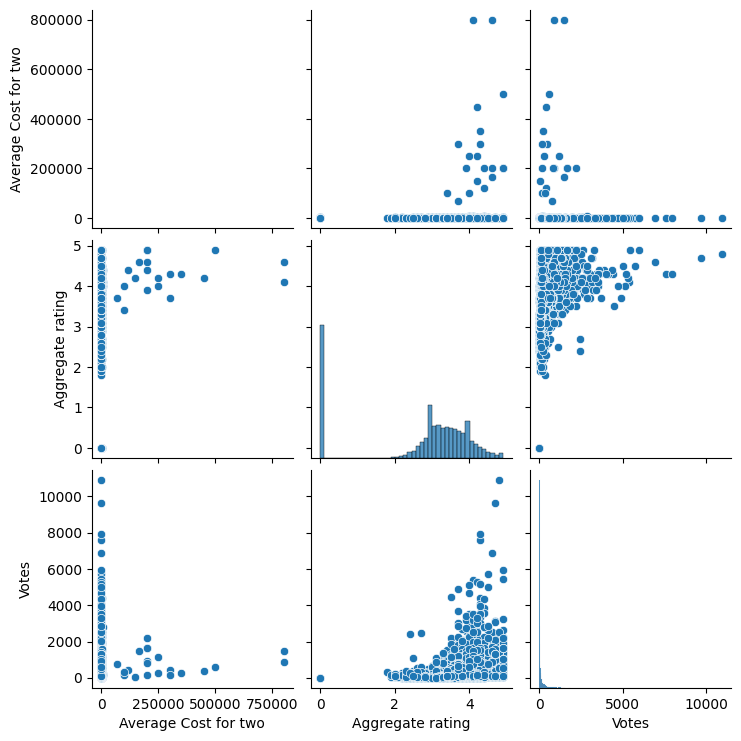

In [16]:
plt.figure(figsize=(7,6))
sns.pairplot(dataset[["Average Cost for two","Aggregate rating","Votes"]])
plt.show()

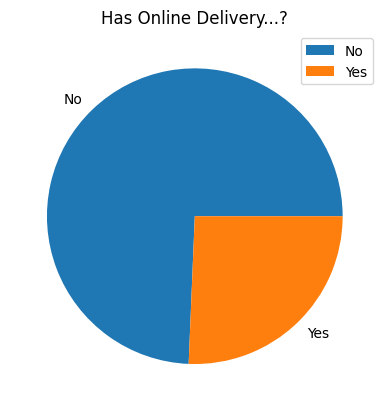

In [17]:
dataset["Has Online delivery"].value_counts().plot(kind="pie")
plt.title("Has Online Delivery...?")
plt.ylabel("")
plt.legend()
plt.show()

In [18]:
dataset[["Aggregate rating","Rating text"]].sort_values(by="Aggregate rating",ascending=True)

,Aggregate rating,Rating text
5544,0.0,Not rated
30,0.0,Not rated
7281,0.0,Not rated
7282,0.0,Not rated
7283,0.0,Not rated
...,...,...
362,4.9,Excellent
39,4.9,Excellent
9524,4.9,Excellent
9540,4.9,Excellent


In [19]:
dataset = dataset[dataset["Rating text"] != "Not rated"]

In [20]:
dataset

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [21]:
9551 - 7403

2148

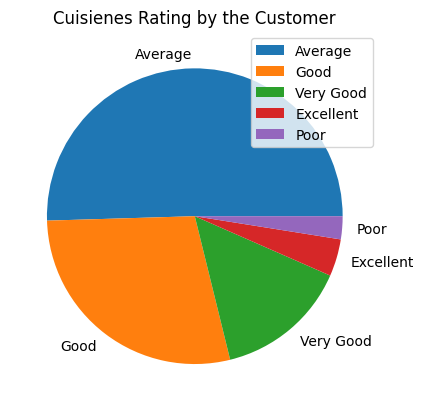

In [22]:
dataset["Rating text"].value_counts().plot(kind="pie")
plt.title("Cuisienes Rating by the Customer")
plt.ylabel("")
plt.legend()
plt.show()

In [23]:
dataset.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [24]:
x = dataset[["Average Cost for two","Has Table booking","Has Online delivery","Price range"]]

In [25]:
y = dataset[["Aggregate rating"]]

In [26]:
x

,Average Cost for two,Has Table booking,Has Online delivery,Price range
0,1100,Yes,No,3
1,1200,Yes,No,3
2,4000,Yes,No,4
3,1500,No,No,4
4,1500,Yes,No,4
...,...,...,...,...
9546,80,No,No,3
9547,105,No,No,3
9548,170,No,No,4
9549,120,No,No,4


In [27]:
y

,Aggregate rating
0,4.8
1,4.5
2,4.4
3,4.9
4,4.8
...,...
9546,4.1
9547,4.2
9548,3.7
9549,4.0


In [28]:
x["Price range"].value_counts()

Price range
1    2744
2    2711
3    1373
4     575
Name: count, dtype: int64

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [30]:
x["Has Table booking"] = le.fit_transform(x["Has Table booking"])

C:\Users\SHREERAM SUNDAR T\AppData\Local\Temp\ipykernel_18780\2071870740.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Has Table booking"] = le.fit_transform(x["Has Table booking"])


In [31]:
x

,Average Cost for two,Has Table booking,Has Online delivery,Price range
0,1100,1,No,3
1,1200,1,No,3
2,4000,1,No,4
3,1500,0,No,4
4,1500,1,No,4
...,...,...,...,...
9546,80,0,No,3
9547,105,0,No,3
9548,170,0,No,4
9549,120,0,No,4


In [32]:
x["Has Online delivery"] = le.fit_transform(x["Has Online delivery"])

C:\Users\SHREERAM SUNDAR T\AppData\Local\Temp\ipykernel_18780\2862216100.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Has Online delivery"] = le.fit_transform(x["Has Online delivery"])


In [33]:
x

,Average Cost for two,Has Table booking,Has Online delivery,Price range
0,1100,1,0,3
1,1200,1,0,3
2,4000,1,0,4
3,1500,0,0,4
4,1500,1,0,4
...,...,...,...,...
9546,80,0,0,3
9547,105,0,0,3
9548,170,0,0,4
9549,120,0,0,4


In [34]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [35]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [36]:
 x = sc.fit_transform(x)

In [37]:
x

array([[-0.0190367 ,  2.37978283, -0.68302371,  1.10671644],
       [-0.0135729 ,  2.37978283, -0.68302371,  1.10671644],
       [ 0.13941344,  2.37978283, -0.68302371,  2.18135204],
       ...,
       [-0.06985002, -0.42020641, -0.68302371,  2.18135204],
       [-0.07258191, -0.42020641, -0.68302371,  2.18135204],
       [-0.07613338, -0.42020641, -0.68302371,  0.03208084]],
      shape=(7403, 4))

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [41]:
def modelresult(predictions):
    print("Mean Absolute Error on Model is {}".format(mean_absolute_error(y_test,predictions)))
    print("Mean Squared Error on Model is {}".format(np.sqrt(mean_squared_error(y_test,predictions))))

In [42]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [43]:
lr.fit(x_train,y_train)

LinearRegression()

In [44]:
predictions_from_lr = lr.predict(x_test)

In [45]:
modelresult(predictions_from_lr)
print("Linear Regression Score :",lr.score(x_train,y_train)*100,lr.score(x_test,y_test)*100)

Mean Absolute Error on Model is 0.40124006807127705
Mean Squared Error on Model is 0.5056738815663485
Linear Regression Score : 17.68807690996311 17.322278802637214


In [46]:
predictions_from_lr

array([[3.22358822],
       [3.42881105],
       [3.16382936],
       ...,
       [3.22330059],
       [3.2240676 ],
       [3.42852342]], shape=(1481, 1))

In [47]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

In [48]:
svr = SVR()

In [49]:
# param_gridsvr = {"C":(0.001,0.01,0.1,0.5),"kernel":("linear","rbf","poly"),"degree":(2,3,4)}    # Takes More Time
param_gridsvr = {"C":(0.1,0.5),"kernel":("linear","poly"),"degree":[2]} 

In [50]:
grid_svr = GridSearchCV(svr,param_gridsvr)
grid_svr.fit(x_train,y_train)

C:\Users\SHREERAM SUNDAR T\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\SHREERAM SUNDAR T\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\SHREERAM SUNDAR T\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\SHREERAM SUNDAR T\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1339: D

GridSearchCV(estimator=SVR(),
             param_grid={'C': (0.1, 0.5), 'degree': [2],
                         'kernel': ('linear', 'poly')})

In [51]:
predictions_from_svr = grid_svr.predict(x_test)

In [52]:
modelresult(predictions_from_svr)
print("SVR Score :",grid_svr.score(x_train,y_train)*100,grid_svr.score(x_test,y_test)*100)

Mean Absolute Error on Model is 0.398669439111988
Mean Squared Error on Model is 0.5080249190569799
SVR Score : 17.043211489093114 16.551701983872302


In [53]:
from sklearn.tree import DecisionTreeRegressor

In [54]:
param_grid = {
    "max_depth" : [10,20],
    "min_samples_leaf" : [1,2],
    "min_samples_split" : [2,5]

}

In [55]:
dtr = DecisionTreeRegressor()

In [56]:
grid_tree = GridSearchCV(estimator=dtr,param_grid=param_grid)

In [57]:
grid_tree.fit(x_train,y_train)

c:\Users\SHREERAM SUNDAR T\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [10, 20], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5]})

In [58]:
tree_predictions = grid_tree.predict(x_test)

In [59]:
modelresult(tree_predictions)
print("Tree Score :",grid_tree.score(x_train,y_train)*100,grid_tree.score(x_test,y_test)*100)

Mean Absolute Error on Model is 0.35554852567379847
Mean Squared Error on Model is 0.4489326826913129
Tree Score : 35.44759952915603 34.835675170277604


In [60]:
from sklearn.ensemble import RandomForestRegressor

In [61]:
rfr = RandomForestRegressor()

In [62]:
param_gridrfr = {
    "max_depth" : [5,15],
    "n_estimators" : [2,5,10]
}

In [63]:
grid_rfr = GridSearchCV(rfr,param_gridrfr)

In [64]:
grid_rfr.fit(x_train,y_train)

C:\Users\SHREERAM SUNDAR T\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\SHREERAM SUNDAR T\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\SHREERAM SUNDAR T\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\SHREERAM SUNDAR T\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1473: DataCon

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 15], 'n_estimators': [2, 5, 10]})

In [65]:
predictions_from_rfr = grid_rfr.predict(x_test)
modelresult(predictions_from_rfr)
print("RFR Score :",grid_rfr.score(x_train,y_train)*100,grid_rfr.score(x_test,y_test)*100)

Mean Absolute Error on Model is 0.3525515328147324
Mean Squared Error on Model is 0.44601668543336753
RFR Score : 32.403499934471355 35.67946255826976


In [66]:
grid_rfr.best_params_

{'max_depth': 5, 'n_estimators': 5}

In [67]:
grid_tree.best_params_

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}

In [68]:
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor()

In [69]:
param_grid_knr = {
    "n_neighbors":[3,5,7,9]
}

In [70]:
grid_knr= GridSearchCV(knr,param_grid_knr)

In [71]:
grid_knr.fit(x_train,y_train)

GridSearchCV(estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': [3, 5, 7, 9]})

In [72]:
predictions_from_knr = grid_knr.predict(x_test)

In [73]:
modelresult(predictions_from_knr)
print("KNR Score :",grid_knr.score(x_train,y_train)*100,grid_knr.score(x_test,y_test)*100)


Mean Absolute Error on Model is 0.3739665391252157
Mean Squared Error on Model is 0.4742779832247601
KNR Score : 26.830952393348774 27.270034489196238


In [74]:
grid_knr.best_params_

{'n_neighbors': 9}

In [76]:
from sklearn.ensemble import AdaBoostRegressor

In [77]:
ada = AdaBoostRegressor()

In [78]:
param_grid_ada = {
    "n_estimators" : [50,100,200],
    "learning_rate":[0.1,0.5,1]
}

In [79]:
grid_ada = GridSearchCV(ada,param_grid_ada)

In [80]:
grid_ada.fit(x_train,y_train)

C:\Users\SHREERAM SUNDAR T\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\SHREERAM SUNDAR T\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\SHREERAM SUNDAR T\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\SHREERAM SUNDAR T\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1339: D

GridSearchCV(estimator=AdaBoostRegressor(),
             param_grid={'learning_rate': [0.1, 0.5, 1],
                         'n_estimators': [50, 100, 200]})

In [81]:
predictions_from_ada = grid_ada.predict(x_test)

In [82]:
modelresult(predictions_from_ada)
print("ADA Score :",grid_ada.score(x_train,y_train)*100,grid_ada.score(x_test,y_test)*100)

Mean Absolute Error on Model is 0.36765914962421686
Mean Squared Error on Model is 0.4607125045546843
ADA Score : 28.833873037793325 31.37103447825228


## Joblib

`joblib` is a Python library that is widely used in machine learning (ML) for efficiently saving and loading large data structures, including trained models. It is particularly useful when working with large NumPy arrays, which are common in ML applications.


## Why Use `joblib` Over `pickle`?

- **Efficient with large NumPy arrays**: Uses memory mapping instead of loading everything into RAM.  
- **Faster I/O operations**: Compressed file formats for better storage.  
- **More robust parallel execution**.  

In [84]:
import joblib
joblib.dump(grid_rfr,"restaurant_rating_predictor.pkl")

['restaurant_rating_predictor.pkl']

In [85]:
scaler = joblib.dump(sc,"scaler.pkl")